In [5]:
import gymnasium as gym
import random
import ale_py

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import seaborn as sns

import collections

import matplotlib.pyplot as plt
import numpy as np

# Make plots look nice
sns.set()
sns.set_context("notebook")
sns.set_style("whitegrid")

gym.register_envs(ale_py)

env = gym.make("ALE/Asterix-v5", obs_type="grayscale", frameskip=1)
env = gym.wrappers.AtariPreprocessing(env, frame_skip=4)
env = gym.wrappers.FrameStackObservation(env, 4)


obs, info = env.reset()


for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)


env.close()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

replay_buffer = collections.deque(maxlen=100000)


In [6]:
def process_obs(obs):
    obs = np.array(obs, dtype=np.float32) / 255.0 
    return torch.tensor(obs, device=device).unsqueeze(0)

In [7]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)
    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Vanilla DQN | Episode 1/500 | Reward: 400
Vanilla DQN | Episode 2/500 | Reward: 250
Vanilla DQN | Episode 3/500 | Reward: 450
Vanilla DQN | Episode 4/500 | Reward: 800
Vanilla DQN | Episode 5/500 | Reward: 500
Vanilla DQN | Episode 6/500 | Reward: 1000
Vanilla DQN | Episode 7/500 | Reward: 650
Vanilla DQN | Episode 8/500 | Reward: 300
Vanilla DQN | Episode 9/500 | Reward: 800
Vanilla DQN | Episode 10/500 | Reward: 550
Vanilla DQN | Episode 11/500 | Reward: 250
Vanilla DQN | Episode 12/500 | Reward: 500
Vanilla DQN | Episode 13/500 | Reward: 200
Vanilla DQN | Episode 14/500 | Reward: 750
Vanilla DQN | Episode 15/500 | Reward: 700
Vanilla DQN | Episode 16/500 | Reward: 250
Vanilla DQN | Episode 17/500 | Reward: 350
Vanilla DQN | Episode 18/500 | Reward: 250
Vanilla DQN | Episode 19/500 | Reward: 400
Vanilla DQN | Episode 20/500 | Reward: 450
Vanilla DQN | Episode 21/500 | Reward: 400
Vanilla DQN | Episode 22/500 | Reward: 200
Vanilla DQN | Episode 23/500 | Reward: 250
Vanilla DQN | Episo

C:\Users\acrab\AppData\Local\Temp\ipykernel_14768\990109253.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=labels, patch_artist=True)


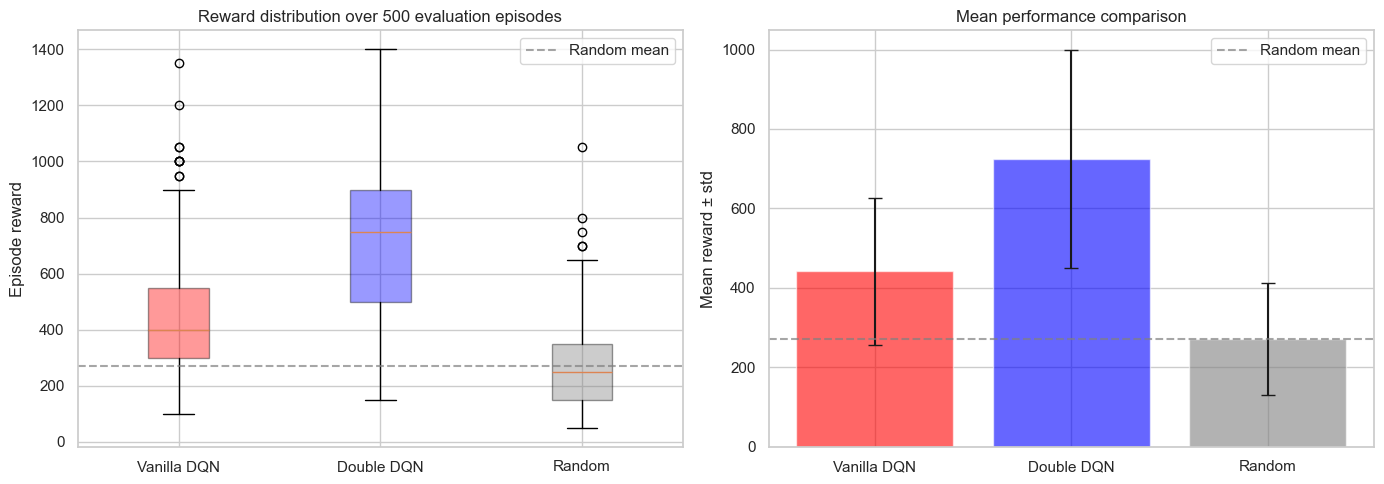

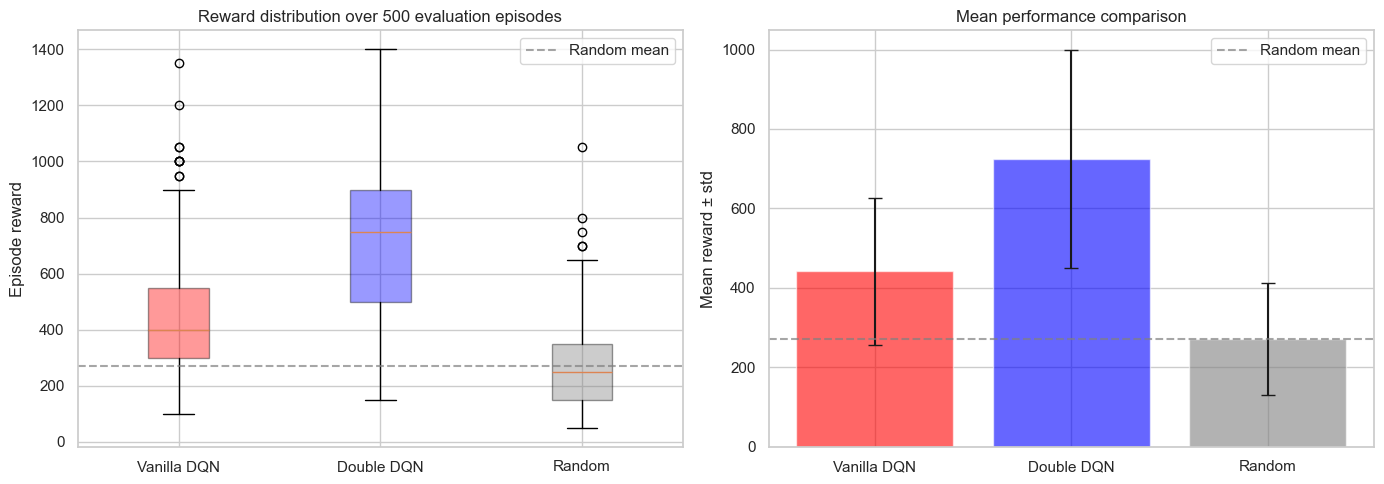

In [22]:
def formal_evaluation(checkpoint_paths, labels, env, device, n_episodes=50):
    results = {}
    
    for path, label in zip(checkpoint_paths, labels):
        Q_net_eval = DQN(env.action_space.n).to(device)
        checkpoint = torch.load(path)
        Q_net_eval.load_state_dict(checkpoint['Q_net'])
        
        rewards = []
        for ep in range(n_episodes):
            obs, info = env.reset()
            obs_t = process_obs(obs)
            done = False
            total = 0
            
            while not done:
                with torch.no_grad():
                    action = Q_net_eval(obs_t).argmax(dim=1).item()
                obs, reward, terminated, truncated, info = env.step(action)
                obs_t = process_obs(obs)
                total += reward
                done = terminated or truncated
            
            rewards.append(total)
            print(f"{label} | Episode {ep+1}/{n_episodes} | Reward: {total:.0f}")
        
        results[label] = rewards
        print(f"\n{label} Results:")
        print(f"  Mean:   {np.mean(rewards):.1f}")
        print(f"  Std:    {np.std(rewards):.1f}")
        print(f"  Median: {np.median(rewards):.1f}")
        print(f"  Best:   {np.max(rewards):.1f}")
        print(f"  Worst:  {np.min(rewards):.1f}\n")
    
    random_rewards = []
    for _ in range(n_episodes):
        obs, info = env.reset()
        done = False
        total = 0
        while not done:
            obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
            total += reward
            done = terminated or truncated
        random_rewards.append(total)
    results['Random'] = random_rewards
    print(f"Random Baseline:")
    print(f"  Mean:   {np.mean(random_rewards):.1f}")
    print(f"  Std:    {np.std(random_rewards):.1f}")
    
    return results


def plot_formal_evaluation(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    labels = list(results.keys())
    data = [results[l] for l in labels]
    colors = ['red', 'blue', 'gray'][:len(labels)]
    
    bp = axes[0].boxplot(data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    random_mean = np.mean(results['Random'])
    axes[0].axhline(y=random_mean, color='gray', linestyle='--', alpha=0.7, label='Random mean')
    axes[0].set_ylabel('Episode reward')
    axes[0].set_title('Reward distribution over 500 evaluation episodes')
    axes[0].legend()
    
    means = [np.mean(results[l]) for l in labels]
    stds  = [np.std(results[l])  for l in labels]
    x = np.arange(len(labels))
    bars = axes[1].bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.6)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('Mean reward ± std')
    axes[1].set_title('Mean performance comparison')
    axes[1].axhline(y=random_mean, color='gray', linestyle='--', alpha=0.7, label='Random mean')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('formal_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


results = formal_evaluation(
    checkpoint_paths=['DQN_full_10k\dqn_checkpoint_ep9999.pt', 'DDQN_eps_V1\ddqn_checkpoint_ep9999.pt'],
    labels=['Vanilla DQN', 'Double DQN'],
    env=env,
    device=device,
    n_episodes=500
)
plot_formal_evaluation(results)

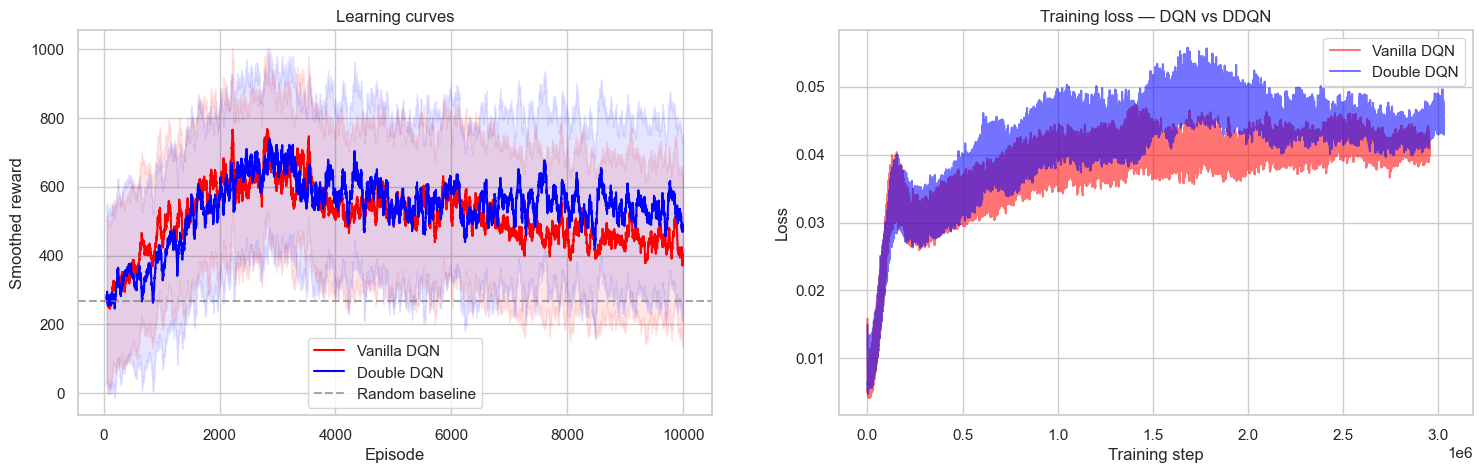

In [31]:
def plot_training_stability(runs, window=50):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    for run in runs:
        rewards = np.array(run['rewards'])

        if len(rewards) >= window:
            smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
            x = range(window - 1, len(rewards))
        else:
            smoothed = rewards
            x = range(len(rewards))

        axes[0].plot(x, smoothed, label=run['label'], color=run['color'])
        axes[0].fill_between(x, smoothed - np.std(rewards[:len(smoothed)]), smoothed + np.std(rewards[:len(smoothed)]), alpha=0.1, color=run['color'])

    axes[0].axhline(y=267, color='gray', linestyle='--', alpha=0.7, label='Random baseline')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Smoothed reward')
    axes[0].set_title('Learning curves')
    axes[0].legend()

    for run in runs:
        losses = np.array(run['losses'])

        if len(losses) >= 1000:
            smoothed_loss = np.convolve(losses, np.ones(1000) / 1000, mode='valid')
            axes[1].plot(smoothed_loss, label=run['label'], color=run['color'], alpha=0.55)

        else:
            axes[1].plot(losses, label=run['label'], color=run['color'], alpha=0.55)

    axes[1].set_xlabel('Training step')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Training loss — DQN vs DDQN')
    axes[1].legend()


dqn_checkpoint = torch.load('DQN_full_10k\dqn_checkpoint_ep9999.pt')
ddqn_checkpoint = torch.load('DDQN_eps_V1\ddqn_checkpoint_ep9999.pt')

runs = [
    {
        'label': 'Vanilla DQN',
        'rewards': dqn_checkpoint['episode_rewards'],
        'losses': dqn_checkpoint['train_losses'],
        'color': 'red',
    },
    {
        'label': 'Double DQN',
        'rewards': ddqn_checkpoint['episode_rewards'],
        'losses': ddqn_checkpoint['train_losses'],
        'color': 'blue',
    },
]

plot_training_stability(runs)

Double DQN epsV1 | Episode 1/500 | Reward: 1050
Double DQN epsV1 | Episode 2/500 | Reward: 800
Double DQN epsV1 | Episode 3/500 | Reward: 500
Double DQN epsV1 | Episode 4/500 | Reward: 750
Double DQN epsV1 | Episode 5/500 | Reward: 1000
Double DQN epsV1 | Episode 6/500 | Reward: 900
Double DQN epsV1 | Episode 7/500 | Reward: 850
Double DQN epsV1 | Episode 8/500 | Reward: 1100
Double DQN epsV1 | Episode 9/500 | Reward: 700
Double DQN epsV1 | Episode 10/500 | Reward: 900
Double DQN epsV1 | Episode 11/500 | Reward: 800
Double DQN epsV1 | Episode 12/500 | Reward: 300
Double DQN epsV1 | Episode 13/500 | Reward: 500
Double DQN epsV1 | Episode 14/500 | Reward: 450
Double DQN epsV1 | Episode 15/500 | Reward: 750
Double DQN epsV1 | Episode 16/500 | Reward: 750
Double DQN epsV1 | Episode 17/500 | Reward: 1200
Double DQN epsV1 | Episode 18/500 | Reward: 1350
Double DQN epsV1 | Episode 19/500 | Reward: 850
Double DQN epsV1 | Episode 20/500 | Reward: 700
Double DQN epsV1 | Episode 21/500 | Reward: 

C:\Users\acrab\AppData\Local\Temp\ipykernel_14768\2901433130.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=labels, patch_artist=True)


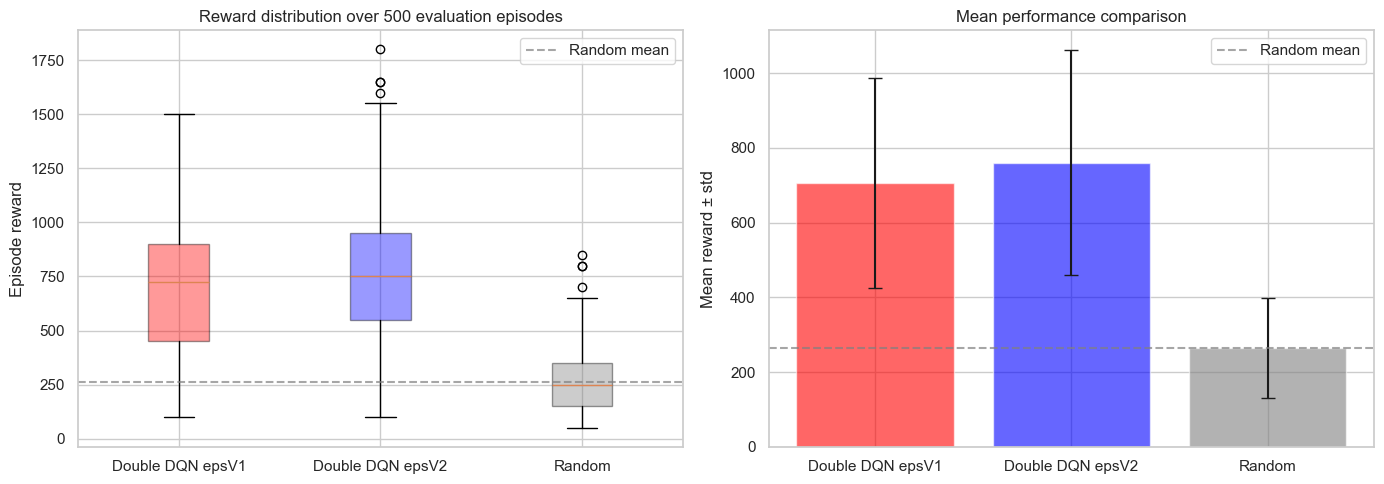

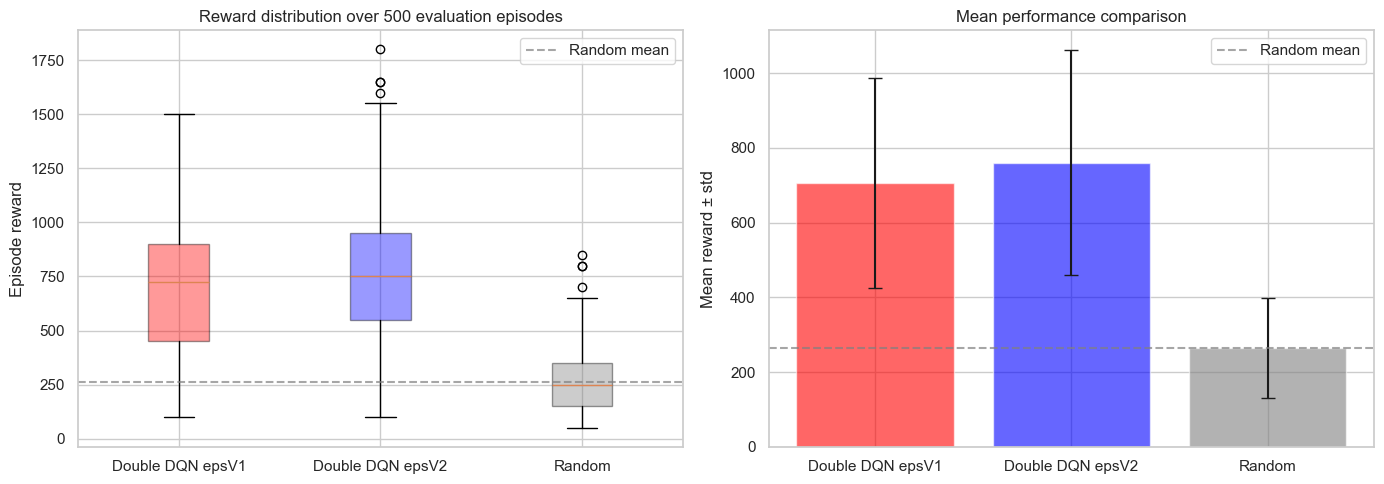

In [23]:
def formal_evaluation(checkpoint_paths, labels, env, device, n_episodes=50):
    results = {}
    
    for path, label in zip(checkpoint_paths, labels):
        Q_net_eval = DQN(env.action_space.n).to(device)
        checkpoint = torch.load(path)
        Q_net_eval.load_state_dict(checkpoint['Q_net'])
        
        rewards = []
        for ep in range(n_episodes):
            obs, info = env.reset()
            obs_t = process_obs(obs)
            done = False
            total = 0
            
            while not done:
                with torch.no_grad():
                    action = Q_net_eval(obs_t).argmax(dim=1).item()
                obs, reward, terminated, truncated, info = env.step(action)
                obs_t = process_obs(obs)
                total += reward
                done = terminated or truncated
            
            rewards.append(total)
            print(f"{label} | Episode {ep+1}/{n_episodes} | Reward: {total:.0f}")
        
        results[label] = rewards
        print(f"\n{label} Results:")
        print(f"  Mean:   {np.mean(rewards):.1f}")
        print(f"  Std:    {np.std(rewards):.1f}")
        print(f"  Median: {np.median(rewards):.1f}")
        print(f"  Best:   {np.max(rewards):.1f}")
        print(f"  Worst:  {np.min(rewards):.1f}\n")
    
    random_rewards = []
    for _ in range(n_episodes):
        obs, info = env.reset()
        done = False
        total = 0
        while not done:
            obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
            total += reward
            done = terminated or truncated
        random_rewards.append(total)
    results['Random'] = random_rewards
    print(f"Random Baseline:")
    print(f"  Mean:   {np.mean(random_rewards):.1f}")
    print(f"  Std:    {np.std(random_rewards):.1f}")
    
    return results


def plot_formal_evaluation(results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    labels = list(results.keys())
    data = [results[l] for l in labels]
    colors = ['red', 'blue', 'gray'][:len(labels)]
    
    bp = axes[0].boxplot(data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.4)

    random_mean = np.mean(results['Random'])
    axes[0].axhline(y=random_mean, color='gray', linestyle='--', alpha=0.7, label='Random mean')
    axes[0].set_ylabel('Episode reward')
    axes[0].set_title('Reward distribution over 500 evaluation episodes')
    axes[0].legend()
    
    means = [np.mean(results[l]) for l in labels]
    stds  = [np.std(results[l])  for l in labels]
    x = np.arange(len(labels))
    bars = axes[1].bar(x, means, yerr=stds, capsize=5, color=colors, alpha=0.6)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('Mean reward ± std')
    axes[1].set_title('Mean performance comparison')
    axes[1].axhline(y=random_mean, color='gray', linestyle='--', alpha=0.7, label='Random mean')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig('formal_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


results = formal_evaluation(
    checkpoint_paths=['DDQN_eps_V1\ddqn_checkpoint_ep9999.pt', 'DDQN_eps_V2\ddqn_checkpoint_ep9999.pt'],
    labels=['Double DQN epsV1', 'Double DQN epsV2'],
    env=env,
    device=device,
    n_episodes=500
)
plot_formal_evaluation(results)

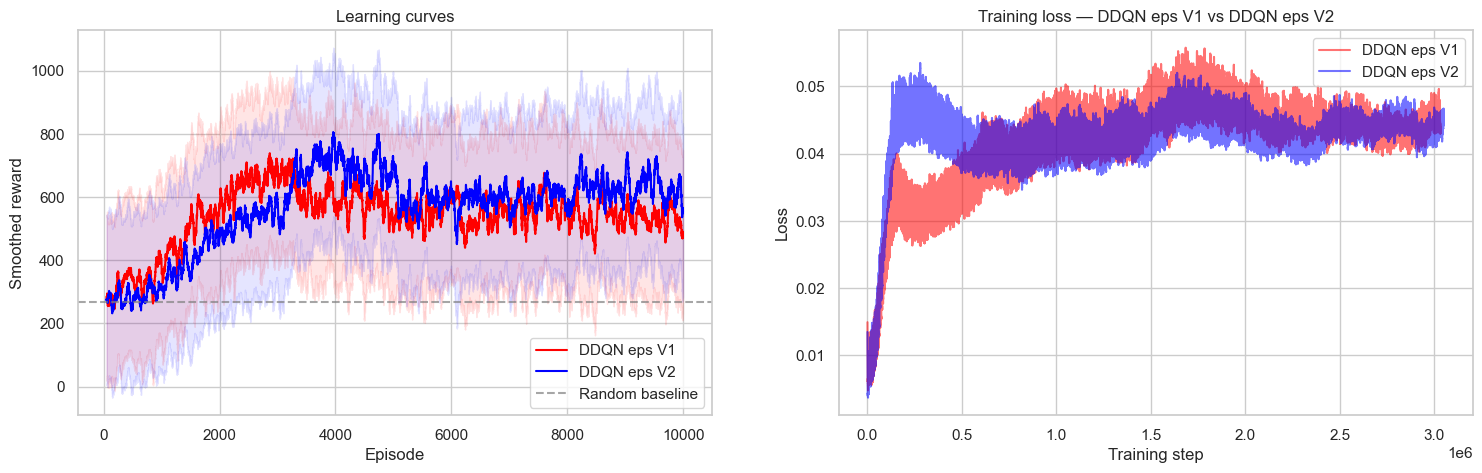

: 

In [ ]:
def plot_training_stability(runs, window=50):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    for run in runs:
        rewards = np.array(run['rewards'])

        if len(rewards) >= window:
            smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
            x = range(window - 1, len(rewards))
        else:
            smoothed = rewards
            x = range(len(rewards))

        axes[0].plot(x, smoothed, label=run['label'], color=run['color'])
        axes[0].fill_between(x, smoothed - np.std(rewards[:len(smoothed)]), smoothed + np.std(rewards[:len(smoothed)]), alpha=0.1, color=run['color'])

    axes[0].axhline(y=267, color='gray', linestyle='--', alpha=0.7, label='Random baseline')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Smoothed reward')
    axes[0].set_title('Learning curves')
    axes[0].legend()

    for run in runs:
        losses = np.array(run['losses'])

        if len(losses) >= 1000:
            smoothed_loss = np.convolve(losses, np.ones(1000) / 1000, mode='valid')
            axes[1].plot(smoothed_loss, label=run['label'], color=run['color'], alpha=0.55)

        else:
            axes[1].plot(losses, label=run['label'], color=run['color'], alpha=0.55)

    axes[1].set_xlabel('Training step')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Training loss — DDQN eps V1 vs DDQN eps V2')
    axes[1].legend()



dqn_checkpoint   = torch.load('DDQN_eps_V1\ddqn_checkpoint_ep9999.pt')
ddqn_checkpoint  = torch.load('DDQN_eps_V2\ddqn_checkpoint_ep9999.pt')

runs = [
    {
        'label': 'DDQN eps V1',
        'rewards': dqn_checkpoint['episode_rewards'],
        'losses': dqn_checkpoint['train_losses'],
        'color': 'red',
    },
    {
        'label': 'DDQN eps V2',
        'rewards': ddqn_checkpoint['episode_rewards'],
        'losses': ddqn_checkpoint['train_losses'],
        'color': 'blue',
    },
]

plot_training_stability(runs)